# Clasificación de Piso en el Dataset UJIIndoorLoc usando Redes Neuronales Artificiales (ANN)

---

## Introducción

En este notebook se replica el flujo de análisis implementado previamente para la clasificación del **piso** en un entorno interior utilizando el dataset **UJIIndoorLoc**, pero en esta ocasión aplicando un modelo de **red neuronal artificial** con capas completamente conectadas (Fully Connected – FC).

El conjunto de datos UJIIndoorLoc contiene mediciones de señales WiFi tomadas en diferentes ubicaciones dentro de un edificio, junto con información asociada como coordenadas, piso, usuario y timestamp. Nuestro objetivo sigue siendo predecir el **piso** en el que se encuentra un dispositivo, tratando el problema como una clasificación multiclase (planta baja, primer piso, segundo piso, etc.).

## Objetivos

- **Cargar y explorar** el conjunto de datos UJIIndoorLoc.
- **Preparar** los datos seleccionando las características relevantes y la variable objetivo (`FLOOR`).
- **Dividir** el dataset en entrenamiento y validación (80/20).
- **Construir** una red neuronal totalmente conectada (fully connected ANN) para clasificar el piso.
- **Diseñar y ajustar** la arquitectura de la red (número de capas, unidades por capa, funciones de activación, etc.).
- **Evaluar el desempeño** del modelo en el conjunto de validación mediante métricas como *accuracy*, *precision*, *recall*, y *F1-score*.
- **Comparar los resultados** obtenidos con los modelos clásicos de clasificación entrenados anteriormente.

Este ejercicio permite evaluar la capacidad de generalización de una red neuronal densa sobre datos del mundo real, comparando su desempeño con algoritmos tradicionales y practicando buenas prácticas en diseño, entrenamiento y evaluación de modelos neuronales.

---


## Descripción del Dataset

El dataset utilizado en este análisis es el **UJIIndoorLoc Dataset**, ampliamente utilizado para tareas de localización en interiores a partir de señales WiFi. Está disponible públicamente en la UCI Machine Learning Repository y ha sido recopilado en un entorno real de un edificio universitario.

Cada muestra corresponde a una observación realizada por un dispositivo móvil, donde se registran las intensidades de señal (RSSI) de más de 500 puntos de acceso WiFi disponibles en el entorno. Además, cada fila contiene información contextual como la ubicación real del dispositivo (coordenadas X e Y), el piso, el edificio, el identificador del usuario, y la marca temporal.

El objetivo en esta tarea es predecir el **piso** (`FLOOR`) en el que se encontraba el dispositivo en el momento de la medición, considerando únicamente las características numéricas provenientes de las señales WiFi.

### Estructura del dataset

- **Número de muestras**: ~20,000
- **Número de características**: 520
  - 520 columnas con valores de intensidad de señal WiFi (`WAP001` a `WAP520`)
- **Variable objetivo**: `FLOOR` (variable categórica con múltiples clases, usualmente entre 0 y 4)

### Columnas relevantes

- `WAP001`, `WAP002`, ..., `WAP520`: niveles de señal recibida desde cada punto de acceso WiFi (valores entre -104 y 0, o 100 si no se detectó).
- `FLOOR`: clase objetivo a predecir (nivel del edificio).
- (Otras columnas como `BUILDINGID`, `SPACEID`, `USERID`, `TIMESTAMP`, etc., pueden ser ignoradas o utilizadas en análisis complementarios).

### Contexto del problema

La localización en interiores es un problema complejo en el que tecnologías como el GPS no funcionan adecuadamente. Los sistemas basados en WiFi han demostrado ser una alternativa efectiva para estimar la ubicación de usuarios en edificios. Poder predecir automáticamente el piso en el que se encuentra una persona puede mejorar aplicaciones de navegación en interiores, accesibilidad, gestión de emergencias y servicios personalizados. Este tipo de problemas es típicamente abordado mediante algoritmos de clasificación multiclase.


### Estrategia de evaluación

En este análisis seguiremos una metodología rigurosa para garantizar la validez de los resultados:

1. **Dataset de entrenamiento**: Se utilizará exclusivamente para el desarrollo, entrenamiento y optimización de hiperparámetros de todos los modelos. Este conjunto será dividido internamente en subconjuntos de entrenamiento y validación (80/20) para la selección de hiperparámetros mediante validación cruzada.

2. **Dataset de prueba**: Se reservará únicamente para la **evaluación final** de los modelos ya optimizados. Este conjunto **no debe ser utilizado** durante el proceso de selección de hiperparámetros, ajuste de modelos o toma de decisiones sobre la arquitectura, ya que esto introduciría sesgo y comprometería la capacidad de generalización estimada.

3. **Validación cruzada**: Para la optimización de hiperparámetros se empleará validación cruzada 5-fold sobre el conjunto de entrenamiento, lo que permitirá una estimación robusta del rendimiento sin contaminar los datos de prueba.

Esta separación estricta entre datos de desarrollo y evaluación final es fundamental para obtener una estimación realista del rendimiento que los modelos tendrían en un escenario de producción con datos completamente nuevos.

---


In [3]:
# === Celda 0: Setup / Configuración base ===
from pathlib import Path
import numpy as np
import pandas as pd

# Semilla global (reproducibilidad)
SEED = 42
rng = np.random.default_rng(SEED)

# Rutas (ajustadas a tu estructura)
DATA_DIR   = Path(r"C:\IA_RigobertoZelayandia\CLase-IA\PROYECTO FINAL\dataset")
TRAIN_PATH = DATA_DIR / "trainingData.csv"
VALID_PATH = DATA_DIR / "validationData.csv"

print("TRAIN_PATH:", TRAIN_PATH)
print("VALID_PATH:", VALID_PATH)
print("Existencia -> train:", TRAIN_PATH.exists(), "| valid:", VALID_PATH.exists())


TRAIN_PATH: C:\IA_RigobertoZelayandia\CLase-IA\PROYECTO FINAL\dataset\trainingData.csv
VALID_PATH: C:\IA_RigobertoZelayandia\CLase-IA\PROYECTO FINAL\dataset\validationData.csv
Existencia -> train: True | valid: True


## Paso 1: Cargar y explorar el dataset

**Instrucciones:**
- Descarga el dataset **UJIIndoorLoc** desde la UCI Machine Learning Repository o utiliza la versión proporcionada en el repositorio del curso (por ejemplo: `datasets\UJIIndoorLoc\trainingData.csv`).
- Carga el dataset utilizando `pandas`.
- Muestra las primeras filas del dataset utilizando `df.head()`.
- Imprime el número total de muestras (filas) y características (columnas).
- Verifica cuántas clases distintas hay en la variable objetivo `FLOOR` y cuántas muestras tiene cada clase (`df['FLOOR'].value_counts()`).


In [4]:
# === PASO 1: Cargar y explorar el dataset (solo TRAIN) ===
import pandas as pd

# 1) Carga (solo datos de entrenamiento / desarrollo)
df = pd.read_csv(TRAIN_PATH)

# 2) Vista rápida
display(df.head())

# 3) Tamaños
n_filas, n_cols = df.shape
print(f"Shape (filas, columnas): {df.shape}")

# 4) Info de columnas y tipos (opcional, pero útil)
print("\nTipos de datos (primeras columnas):")
print(df.dtypes.head(10))

# 5) Clases de la variable objetivo FLOOR
if "FLOOR" not in df.columns:
    raise ValueError("No se encontró la columna 'FLOOR' en el dataset de entrenamiento.")

vc = df["FLOOR"].value_counts().sort_index()
print("\nClases distintas en FLOOR:", sorted(df["FLOOR"].unique()))
print("\nConteo por clase (FLOOR):")
print(vc)

print("\nDistribución porcentual por clase (FLOOR):")
print((vc / vc.sum() * 100).round(2).astype(str) + "%")

# --- Nota importante (recordatorio) ---
print("\n[AVISO] El archivo 'validationData.csv' se usará SOLO para la evaluación final.\n"
      "No se usará en ajuste de hiperparámetros ni decisiones de modelo.")


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710


Shape (filas, columnas): (19937, 529)

Tipos de datos (primeras columnas):
WAP001    int64
WAP002    int64
WAP003    int64
WAP004    int64
WAP005    int64
WAP006    int64
WAP007    int64
WAP008    int64
WAP009    int64
WAP010    int64
dtype: object

Clases distintas en FLOOR: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Conteo por clase (FLOOR):
FLOOR
0    4369
1    5002
2    4416
3    5048
4    1102
Name: count, dtype: int64

Distribución porcentual por clase (FLOOR):
FLOOR
0    21.91%
1    25.09%
2    22.15%
3    25.32%
4     5.53%
Name: count, dtype: object

[AVISO] El archivo 'validationData.csv' se usará SOLO para la evaluación final.
No se usará en ajuste de hiperparámetros ni decisiones de modelo.


---

## Paso 2: Preparar los datos

**Instrucciones:**

- Elimina las columnas que no son relevantes para la tarea de clasificación del piso:
  - `LONGITUDE`, `LATITUDE`, `SPACEID`, `RELATIVEPOSITION`, `USERID`, `PHONEID`, `TIMESTAMP`
- Conserva únicamente:
  - Las columnas `WAP001` a `WAP520` como características (RSSI de puntos de acceso WiFi).
  - La columna `FLOOR` como variable objetivo.
- Verifica si existen valores atípicos o valores inválidos en las señales WiFi (por ejemplo: valores constantes como 100 o -110 que suelen indicar ausencia de señal).
- Separa el conjunto de datos en:
  - `X`: matriz de características (todas las columnas `WAP`)
  - `y`: vector objetivo (`FLOOR`)


In [5]:
import numpy as np
import pandas as pd
import re

# 0) Comprobar que 'df' existe (del Paso 1, TRAIN cargado)
assert 'df' in globals(), "Primero ejecuta el Paso 1 para cargar el dataset de entrenamiento en 'df'."

# 1) Columnas no relevantes (si alguna no existe, se ignora sin error)
DROP_COLS = ['LONGITUDE','LATITUDE','SPACEID','RELATIVEPOSITION','USERID','PHONEID','TIMESTAMP']
df2 = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')

# 2) Detectar columnas WAP: nombres tipo WAP001..WAP520
WAP_COLS = sorted([c for c in df2.columns if re.fullmatch(r"WAP\d{3}", c)])
if not WAP_COLS:
    raise ValueError("No se encontraron columnas WAP (patrón WAP###) en el dataset.")

# 3) Asegurar que FLOOR existe y es entero
if "FLOOR" not in df2.columns:
    raise ValueError("No se encontró la columna 'FLOOR' en el dataset de entrenamiento.")
y = df2["FLOOR"].astype(int)

# 4) Asegurar numéricos en WAPs (si hubiera strings, se fuerzan; valores no convertibles -> NaN)
df2[WAP_COLS] = df2[WAP_COLS].apply(pd.to_numeric, errors="coerce")

# 5) Separar matriz de características X (solo WAPs)
X = df2[WAP_COLS].copy()

print(f"Total de WAPs seleccionadas: {len(WAP_COLS)}")
print(f"Shape X: {X.shape} | Shape y: {y.shape}")

# 6) Revisión de valores típicos de ausencia/ruido en señal
total_vals = X.size
cnt_100   = np.sum(X.values == 100)     # convención muy usada para "sin señal"
cnt_m110  = np.sum(X.values == -110)    # otra convención posible
cnt_nan   = np.isnan(X.values).sum()

print("\n--- Chequeo de valores 'inválidos' o marcadores de ausencia de señal ---")
print(f"Valores 100   : {cnt_100:,}  ({cnt_100/total_vals:.2%})")
print(f"Valores -110  : {cnt_m110:,}  ({cnt_m110/total_vals:.2%})")
print(f"Valores NaN   : {cnt_nan:,}   ({cnt_nan/total_vals:.2%})")

# 7) Top 10 WAP con mayor proporción de (100, -110 o NaN)
ratio_invalid = ((X == 100) | (X == -110) | X.isna()).mean()
top_bad = ratio_invalid.sort_values(ascending=False).head(10).to_frame("ratio_invalid")
print("\nTop 10 WAP con mayor proporción de valores inválidos:")
display(top_bad.style.format({"ratio_invalid": "{:.2%}"}))

# 8) Guardar copias para siguientes pasos
X_train_raw = X.copy()   # versión "cruda" para paso 3 (mapeo 100 -> -100)
y_train     = y.copy()




Total de WAPs seleccionadas: 520
Shape X: (19937, 520) | Shape y: (19937,)

--- Chequeo de valores 'inválidos' o marcadores de ausencia de señal ---
Valores 100   : 10,008,477  (96.54%)
Valores -110  : 0  (0.00%)
Valores NaN   : 0   (0.00%)

Top 10 WAP con mayor proporción de valores inválidos:


,ratio_invalid
WAP520,100.00%
WAP497,100.00%
WAP491,100.00%
WAP487,100.00%
WAP488,100.00%
WAP485,100.00%
WAP482,100.00%
WAP247,100.00%
WAP451,100.00%
WAP458,100.00%


--- 

## Paso 3: Preprocesamiento de las señales WiFi

**Contexto:**

Las columnas `WAP001` a `WAP520` representan la intensidad de la señal (RSSI) recibida desde distintos puntos de acceso WiFi. Los valores típicos de RSSI están en una escala negativa, donde:

- Valores cercanos a **0 dBm** indican señal fuerte.
- Valores cercanos a **-100 dBm** indican señal débil o casi ausente.
- Un valor de **100** en este dataset representa una señal **no detectada**, es decir, el punto de acceso no fue visto por el dispositivo en ese instante.

**Instrucciones:**

- Para facilitar el procesamiento y tratar la ausencia de señal de forma coherente, se recomienda mapear todos los valores **100** a **-100**, que semánticamente representa *ausencia de señal detectable*.
- Esto unifica el rango de valores y evita que 100 (un valor artificial) afecte negativamente la escala de los algoritmos.

**Pasos sugeridos:**

- Reemplaza todos los valores `100` por `-100` en las columnas `WAP001` a `WAP520`:
  ```python
  X[X == 100] = -100


In [6]:
# === PASO 3: Preprocesamiento de señales (solo TRAIN) ===

import numpy as np
import pandas as pd

def preprocess_wifi(X, fill_missing_with=-110):
    Xp = X.copy()
    # 1) Mapear 100 -> -100
    Xp = Xp.replace(100, -100)
    # 2) (Opcional) Imputar NaN si hubiesen
    if fill_missing_with is not None:
        Xp = Xp.fillna(fill_missing_with)
    # 3) (Opcional) Limitar a un rango típico [-110, 0] para evitar outliers raros
    Xp = Xp.clip(lower=-110, upper=0)
    return Xp

# Comprobación de que venimos del Paso 2
assert 'X_train_raw' in globals() and 'y_train' in globals(), \
       "Primero ejecuta el Paso 2 (X_train_raw, y_train)."

# --- conteo antes ---
total_vals = X_train_raw.size
cnt_100   = np.sum(X_train_raw.values == 100)
cnt_m110  = np.sum(X_train_raw.values == -110)
cnt_nan   = np.isnan(X_train_raw.values).sum()
print("[ANTES] 100:", cnt_100, "| -110:", cnt_m110, "| NaN:", cnt_nan, f"| total={total_vals}")

# Procesar
X_train = preprocess_wifi(X_train_raw, fill_missing_with=-110)

# --- conteo después ---
total_vals2 = X_train.size
cnt_100_2   = np.sum(X_train.values == 100)
cnt_m100_2  = np.sum(X_train.values == -100)
cnt_m110_2  = np.sum(X_train.values == -110)
cnt_nan_2   = np.isnan(X_train.values).sum()

print("[DESPUÉS] 100:", cnt_100_2,
      "| -100:", cnt_m100_2,
      "| -110:", cnt_m110_2,
      "| NaN:", cnt_nan_2,
      f"| total={total_vals2}")



[ANTES] 100: 10008477 | -110: 0 | NaN: 0 | total=10367240
[DESPUÉS] 100: 0 | -100: 10008716 | -110: 0 | NaN: 0 | total=10367240


---

## Paso 4: Preparación del dataset

**Objetivo:**

Diseñar una función que cargue el dataset **UJIIndoorLoc**, realice limpieza básica si es necesario, normalice las variables predictoras, y divida los datos en tres subconjuntos de forma estratificada para su uso en redes neuronales.

**Esquema de partición:**

1. **20% del dataset se reserva como conjunto de testeo final.**
2. **El 80% restante se subdivide en:**
   - **80% para entrenamiento** → equivale al 64% del total.
   - **20% para validación** → equivale al 16% del total.

  En este caso, ya existe un conjunto de testeo definido por separado. Por lo tanto, la función solo debe dividir el dataset de entrenamiento original en dos subconjuntos estratificados:

  - **80% para entrenamiento**
  - **20% para validación**

**Requisitos de la función:**

- La función debe realizar las siguientes tareas:
  1. Cargar el archivo `.csv` del dataset.
  2. Seleccionar las columnas de entrada (features) y la variable objetivo (`FLOOR`).
  3. Aplicar normalización a las variables predictoras utilizando `MinMaxScaler` para que todos los valores queden entre 0 y 1.
  4. Realizar las divisiones del conjunto de datos en el orden indicado, asegurando estratificación según la variable objetivo.
  
- La función debe recibir como parámetros:
  - La ruta al archivo `.csv` del dataset.
  - El nombre de la columna objetivo (por ejemplo, `FLOOR`).
  - Un parámetro `random_state` para asegurar reproducibilidad de las divisiones.

- La función debe retornar:
  - `X_train`, `X_val`, `X_test`: subconjuntos de características normalizadas.
  - `y_train`, `y_val`, `y_test`: subconjuntos de etiquetas, codificadas si es necesario para clasificación multiclase.

**Nota:** Esta función es fundamental para garantizar un flujo de entrenamiento robusto y reproducible en redes neuronales.


In [9]:
# === PASO 4: Entrenamiento + Optimización (solo con TRAIN) ===
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Comprobación de que venimos del paso 3
assert 'X_train' in globals() and 'y_train' in globals(), \
       "Primero ejecuta los pasos 1–3 para tener X_train e y_train."

SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = []
best_models = {}

def run_grid(name, pipe, param_grid, scoring='accuracy', cv=cv):
    """Helper: entrena GridSearchCV, guarda mejor CV y el mejor estimador."""
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)
    print(f"{name:12s} | best_cv={gs.best_score_:.4f} | params={gs.best_params_}")
    results.append({
        "modelo": name,
        "best_cv": gs.best_score_,
        "best_params": gs.best_params_,
        "best_estimator": gs.best_estimator_
    })
    best_models[name] = gs.best_estimator_
    return gs

# ---------- KNN ----------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])
param_grid = {
    "clf__n_neighbors": [3, 5, 7, 9],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],  # Manhattan / Euclídea
}
gs_knn = run_grid("KNN", pipe, param_grid)

# ---------- Gaussian Naive Bayes ----------
pipe = Pipeline([
    ("clf", GaussianNB())
])
param_grid = {
    "clf__var_smoothing": [1e-9, 1e-8, 1e-7]
}
gs_gnb = run_grid("GaussianNB", pipe, param_grid)

# ---------- Regresión Logística ----------
# Nota: lbfgs funciona bien con multiclase; escalado en pipeline.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])
param_grid = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__solver": ["lbfgs"],  # estable para multiclase
}
gs_lr = run_grid("LogReg", pipe, param_grid)

# ---------- Árbol de Decisión ----------
pipe = Pipeline([
    ("clf", DecisionTreeClassifier(random_state=SEED))
])
param_grid = {
    "clf__max_depth": [10, 20, 30, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 5],
}
gs_dt = run_grid("DecisionTree", pipe, param_grid)

# ---------- SVM (RBF) ----------
# SVM suele ser costoso; grid compacto + escalado.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", cache_size=1000, random_state=SEED))
])
param_grid = {
    "clf__C": [1, 10, 100],
    "clf__gamma": ["scale", 0.01, 0.001],
}
gs_svm = run_grid("SVM (rbf)", pipe, param_grid)

# ---------- Random Forest ----------
pipe = Pipeline([
    ("clf", RandomForestClassifier(
        random_state=SEED, n_jobs=-1
    ))
])
param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 20, 40],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2],
}
gs_rf = run_grid("RandomForest", pipe, param_grid)

# ---------- Resumen ordenado por mejor CV ----------
summary = (
    pd.DataFrame([{k: v for k, v in r.items() if k != "best_estimator"} for r in results])
    .sort_values("best_cv", ascending=False)
    .reset_index(drop=True)
)
display(summary)

print("\n[OK] Paso 4 completado. 'best_models' contiene los mejores estimadores por modelo.")


KNN          | best_cv=0.9954 | params={'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance'}
GaussianNB   | best_cv=0.5830 | params={'clf__var_smoothing': 1e-07}
LogReg       | best_cv=0.9933 | params={'clf__C': 1.0, 'clf__solver': 'lbfgs'}
DecisionTree | best_cv=0.9720 | params={'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
SVM (rbf)    | best_cv=0.9940 | params={'clf__C': 10, 'clf__gamma': 0.001}
RandomForest | best_cv=0.9966 | params={'clf__max_depth': 40, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}


,modelo,best_cv,best_params
0,RandomForest,0.996589,"{'clf__max_depth': 40, 'clf__min_samples_leaf'..."
1,KNN,0.995436,"{'clf__n_neighbors': 3, 'clf__p': 1, 'clf__wei..."
2,SVM (rbf),0.993981,"{'clf__C': 10, 'clf__gamma': 0.001}"
3,LogReg,0.993329,"{'clf__C': 1.0, 'clf__solver': 'lbfgs'}"
4,DecisionTree,0.972012,"{'clf__max_depth': None, 'clf__min_samples_lea..."
5,GaussianNB,0.582986,{'clf__var_smoothing': 1e-07}



[OK] Paso 4 completado. 'best_models' contiene los mejores estimadores por modelo.


---
## Paso 5: Entrenamiento de redes neuronales artificiales (ANN)

**Objetivo:**

Entrenar y comparar el rendimiento de diferentes arquitecturas de redes neuronales totalmente conectadas (**Fully Connected ANN**) utilizando **PyTorch** para predecir el piso (`FLOOR`) en el dataset UJIIndoorLoc. El objetivo es observar el impacto de la profundidad y la expansión/compresión de capas sobre el rendimiento del modelo.

**Entorno y configuración:**

- **Framework:** PyTorch
- **Función de pérdida:** `nn.CrossEntropyLoss()`  
  > Esta función es equivalente a `sparse_categorical_crossentropy`, por lo que **no es necesario one-hot encoding** en las etiquetas.
- **Optimizador:** `torch.optim.Adam`
- **Activación:** `ReLU` en todas las capas ocultas
- **Salida:** `Softmax` (implícito en `CrossEntropyLoss`)
- **Épocas:** 20
- **Batch size: 32**
- **Sin Dropout ni BatchNormalization**


### Arquitecturas a evaluar

1. **Arquitectura 1: Compacta**
   ```text
   Input (520)
   → Linear(128) + ReLU
   → Linear(4)
   ```

2. **Arquitectura 2: Dos capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(4)
   ```

3. **Arquitectura 3: Tres capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64) + ReLU
   → Linear(4)
   ```

4. **Arquitectura 4: Pirámide profunda**
   ```text
   Input (520)
   → Linear(512) + ReLU
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64)  + ReLU
   → Linear(4)
   ```

5. **Arquitectura 5: Expansiva y luego compresiva**
   ```text
   Input (520)
   → Linear(1024) + ReLU
   → Linear(512)  + ReLU
   → Linear(256)  + ReLU
   → Linear(128)  + ReLU
   → Linear(64)   + ReLU
   → Linear(4)
   ```


### Instrucciones

- Implementa cada arquitectura como una subclase de `nn.Module` en PyTorch.
- Entrena durante **20 épocas**, utilizando el conjunto de entrenamiento (`X_train`, `y_train`) y validación (`X_val`, `y_val`).
- Registra la **pérdida de entrenamiento y validación** por época en un gráfico.
- Grafica la evolución de la pérdida para analizar tendencias de aprendizaje, sobreajuste o subajuste.
- Evalúa el modelo final con el conjunto de test (`X_test`, `y_test`) y reporta:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**

N_INPUT=520 | N_CLASSES=5
X_tr: (15949, 520) X_val: (3988, 520) X_te: (1111, 520)

== Entrenando ANN1_Compacta ==
Epoch 01/20 | train_loss=0.1766 | val_loss=0.0309
Epoch 02/20 | train_loss=0.0188 | val_loss=0.0271
Epoch 03/20 | train_loss=0.0116 | val_loss=0.0185
Epoch 04/20 | train_loss=0.0093 | val_loss=0.0252
Epoch 05/20 | train_loss=0.0072 | val_loss=0.0234
Epoch 06/20 | train_loss=0.0093 | val_loss=0.0218
Epoch 07/20 | train_loss=0.0066 | val_loss=0.0200
Epoch 08/20 | train_loss=0.0069 | val_loss=0.0270
Epoch 09/20 | train_loss=0.0069 | val_loss=0.0249
Epoch 10/20 | train_loss=0.0057 | val_loss=0.0200
Epoch 11/20 | train_loss=0.0061 | val_loss=0.0180
Epoch 12/20 | train_loss=0.0074 | val_loss=0.0190
Epoch 13/20 | train_loss=0.0053 | val_loss=0.0181
Epoch 14/20 | train_loss=0.0049 | val_loss=0.0287
Epoch 15/20 | train_loss=0.0084 | val_loss=0.0228
Epoch 16/20 | train_loss=0.0053 | val_loss=0.0270
Epoch 17/20 | train_loss=0.0049 | val_loss=0.0251
Epoch 18/20 | train_loss=0.0046 | va

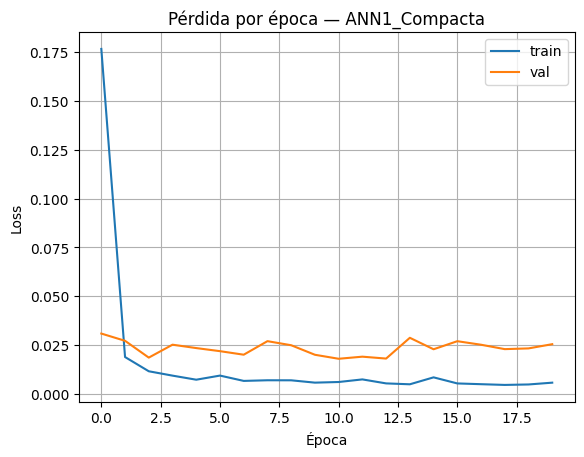


== Entrenando ANN2_DosCapas ==
Epoch 01/20 | train_loss=0.1306 | val_loss=0.0356
Epoch 02/20 | train_loss=0.0302 | val_loss=0.0320
Epoch 03/20 | train_loss=0.0177 | val_loss=0.0215
Epoch 04/20 | train_loss=0.0095 | val_loss=0.0208
Epoch 05/20 | train_loss=0.0097 | val_loss=0.0269
Epoch 06/20 | train_loss=0.0099 | val_loss=0.0257
Epoch 07/20 | train_loss=0.0214 | val_loss=0.0161
Epoch 08/20 | train_loss=0.0057 | val_loss=0.0145
Epoch 09/20 | train_loss=0.0099 | val_loss=0.0238
Epoch 10/20 | train_loss=0.0119 | val_loss=0.0373
Epoch 11/20 | train_loss=0.0120 | val_loss=0.0238
Epoch 12/20 | train_loss=0.0064 | val_loss=0.0340
Epoch 13/20 | train_loss=0.0110 | val_loss=0.0248
Epoch 14/20 | train_loss=0.0116 | val_loss=0.0589
Epoch 15/20 | train_loss=0.0138 | val_loss=0.0467
Epoch 16/20 | train_loss=0.0086 | val_loss=0.0342
Epoch 17/20 | train_loss=0.0049 | val_loss=0.0354
Epoch 18/20 | train_loss=0.0042 | val_loss=0.0332
Epoch 19/20 | train_loss=0.0038 | val_loss=0.0326
Epoch 20/20 | trai

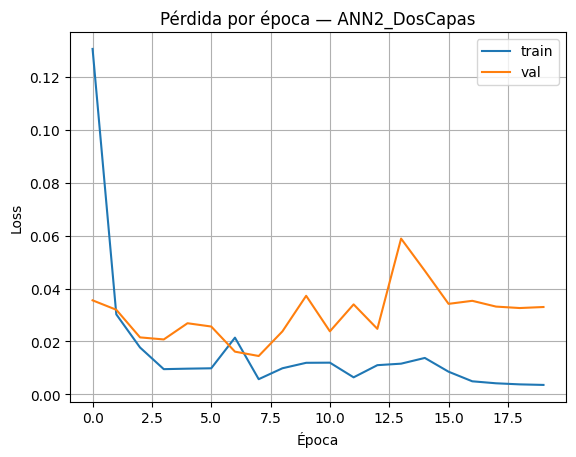


== Entrenando ANN3_TresCapas ==
Epoch 01/20 | train_loss=0.1419 | val_loss=0.0490
Epoch 02/20 | train_loss=0.0322 | val_loss=0.0318
Epoch 03/20 | train_loss=0.0155 | val_loss=0.0225
Epoch 04/20 | train_loss=0.0184 | val_loss=0.0293
Epoch 05/20 | train_loss=0.0127 | val_loss=0.0273
Epoch 06/20 | train_loss=0.0189 | val_loss=0.0207
Epoch 07/20 | train_loss=0.0144 | val_loss=0.0264
Epoch 08/20 | train_loss=0.0071 | val_loss=0.0204
Epoch 09/20 | train_loss=0.0086 | val_loss=0.0248
Epoch 10/20 | train_loss=0.0104 | val_loss=0.0357
Epoch 11/20 | train_loss=0.0126 | val_loss=0.1197
Epoch 12/20 | train_loss=0.0111 | val_loss=0.0163
Epoch 13/20 | train_loss=0.0061 | val_loss=0.0272
Epoch 14/20 | train_loss=0.0070 | val_loss=0.0390
Epoch 15/20 | train_loss=0.0121 | val_loss=0.0228
Epoch 16/20 | train_loss=0.0037 | val_loss=0.0198
Epoch 17/20 | train_loss=0.0038 | val_loss=0.0289
Epoch 18/20 | train_loss=0.0205 | val_loss=0.0224
Epoch 19/20 | train_loss=0.0118 | val_loss=0.0217
Epoch 20/20 | tra

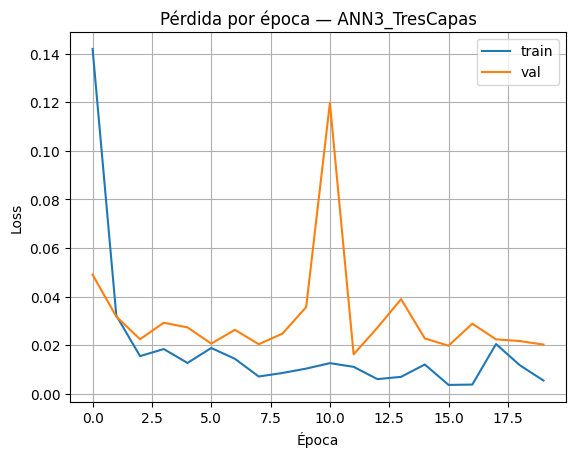


== Entrenando ANN4_Piramide ==
Epoch 01/20 | train_loss=0.1494 | val_loss=0.0426
Epoch 02/20 | train_loss=0.0345 | val_loss=0.0324
Epoch 03/20 | train_loss=0.0262 | val_loss=0.0324
Epoch 04/20 | train_loss=0.0182 | val_loss=0.0372
Epoch 05/20 | train_loss=0.0130 | val_loss=0.0211
Epoch 06/20 | train_loss=0.0178 | val_loss=0.0816
Epoch 07/20 | train_loss=0.0193 | val_loss=0.0812
Epoch 08/20 | train_loss=0.0217 | val_loss=0.0281
Epoch 09/20 | train_loss=0.0128 | val_loss=0.0276
Epoch 10/20 | train_loss=0.0108 | val_loss=0.0214
Epoch 11/20 | train_loss=0.0122 | val_loss=0.0218
Epoch 12/20 | train_loss=0.0127 | val_loss=0.0211
Epoch 13/20 | train_loss=0.0070 | val_loss=0.0339
Epoch 14/20 | train_loss=0.0127 | val_loss=0.0235
Epoch 15/20 | train_loss=0.0114 | val_loss=0.0232
Epoch 16/20 | train_loss=0.0119 | val_loss=0.0245
Epoch 17/20 | train_loss=0.0088 | val_loss=0.0580
Epoch 18/20 | train_loss=0.0180 | val_loss=0.0289
Epoch 19/20 | train_loss=0.0064 | val_loss=0.0445
Epoch 20/20 | trai

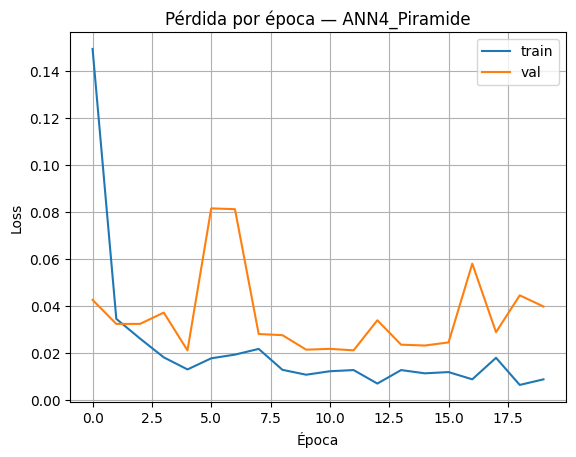


== Entrenando ANN5_ExpComp ==
Epoch 01/20 | train_loss=0.1830 | val_loss=0.0492
Epoch 02/20 | train_loss=0.0520 | val_loss=0.0542
Epoch 03/20 | train_loss=0.0349 | val_loss=0.0310
Epoch 04/20 | train_loss=0.0208 | val_loss=0.0258
Epoch 05/20 | train_loss=0.0180 | val_loss=0.0297
Epoch 06/20 | train_loss=0.0407 | val_loss=0.0305
Epoch 07/20 | train_loss=0.0159 | val_loss=0.0351
Epoch 08/20 | train_loss=0.0141 | val_loss=0.0595
Epoch 09/20 | train_loss=0.0233 | val_loss=0.0314
Epoch 10/20 | train_loss=0.0187 | val_loss=0.0299
Epoch 11/20 | train_loss=0.0069 | val_loss=0.0389
Epoch 12/20 | train_loss=0.0117 | val_loss=0.0823
Epoch 13/20 | train_loss=0.0240 | val_loss=0.0466
Epoch 14/20 | train_loss=0.0160 | val_loss=0.0530
Epoch 15/20 | train_loss=0.0256 | val_loss=0.0245
Epoch 16/20 | train_loss=0.0129 | val_loss=0.0439
Epoch 17/20 | train_loss=0.0105 | val_loss=0.0317
Epoch 18/20 | train_loss=0.0059 | val_loss=0.0445
Epoch 19/20 | train_loss=0.0227 | val_loss=0.0268
Epoch 20/20 | train

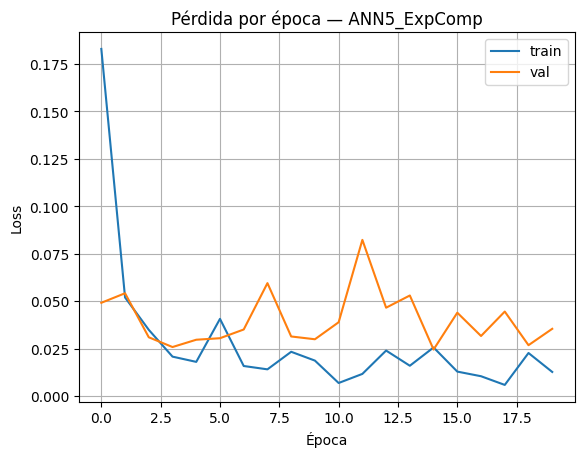


== Evaluación en test: ANN1_Compacta ==


RuntimeError: Numpy is not available

In [42]:
# =========================
# PASO 5: Redes Neuronales (ANN) con PyTorch
# =========================

# --- Imports ---
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# --- Configuración base ---
SEED       = 42
EPOCHS     = 20
BATCH_SIZE = 32
LR         = 1e-3
device     = torch.device("cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Tomar lo preparado en pasos previos (X_train, y_train, X_test, y_test) ---
X_tr_all = np.asarray(X_train, dtype=np.float32)
y_tr_all = np.asarray(y_train)
X_te_all = np.asarray(X_test,  dtype=np.float32)
y_te_all = np.asarray(y_test)

# --- Split 80/20 estratificado por FLOOR ---
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr_all, y_tr_all, test_size=0.20, random_state=SEED, stratify=y_tr_all
)

# --- Escalado: fit SOLO en train; transformar val y test ---
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)
X_te  = scaler.transform(X_te_all).astype(np.float32)

# --- Shapes y n_clases ---
N_INPUT   = X_tr.shape[1]                      # (debería ser 520)
N_CLASSES = int(np.unique(y_tr_all).shape[0])  # (debería ser 4)
print(f"N_INPUT={N_INPUT} | N_CLASSES={N_CLASSES}")
print("X_tr:", X_tr.shape, "X_val:", X_val.shape, "X_te:", X_te.shape)

# --- DataLoaders ---
def make_loader(X, y, shuffle, bs=BATCH_SIZE):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=bs, shuffle=shuffle)

train_loader = make_loader(X_tr, y_tr, True)
val_loader   = make_loader(X_val, y_val, False)
test_loader  = make_loader(X_te, y_te_all, False)

# =========================
# 5.2 Arquitecturas (PyTorch)
# =========================

class ANN1_Compacta(nn.Module):
    # Input (520) -> Linear(128)+ReLU -> Linear(4)
    def __init__(self, in_dim=N_INPUT, out_dim=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, out_dim)
        )
    def forward(self, x): return self.net(x)

class ANN2_DosCapas(nn.Module):
    # 520 -> 256 -> 128 -> 4
    def __init__(self, in_dim=N_INPUT, out_dim=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, out_dim)
        )
    def forward(self, x): return self.net(x)

class ANN3_TresCapas(nn.Module):
    # 520 -> 256 -> 128 -> 64 -> 4
    def __init__(self, in_dim=N_INPUT, out_dim=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, out_dim)
        )
    def forward(self, x): return self.net(x)

class ANN4_Piramide(nn.Module):
    # 520 -> 512 -> 256 -> 128 -> 64 -> 4
    def __init__(self, in_dim=N_INPUT, out_dim=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 512), nn.ReLU(),
            nn.Linear(512, 256),    nn.ReLU(),
            nn.Linear(256, 128),    nn.ReLU(),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, out_dim)
        )
    def forward(self, x): return self.net(x)

class ANN5_ExpComp(nn.Module):
    # 520 -> 1024 -> 512 -> 256 -> 128 -> 64 -> 4
    def __init__(self, in_dim=N_INPUT, out_dim=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 1024), nn.ReLU(),
            nn.Linear(1024, 512),    nn.ReLU(),
            nn.Linear(512, 256),     nn.ReLU(),
            nn.Linear(256, 128),     nn.ReLU(),
            nn.Linear(128, 64),      nn.ReLU(),
            nn.Linear(64, out_dim)
        )
    def forward(self, x): return self.net(x)

# =========================
# 5.3 Entrenamiento (20 épocas) + registro de pérdidas
# =========================

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, device=device):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimz    = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}
    best_state = None
    best_val   = np.inf
    t0 = time.time()

    for ep in range(1, epochs + 1):
        # --- train ---
        model.train()
        run = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimz.zero_grad()
            out  = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimz.step()
            run += loss.item() * xb.size(0)
        train_loss = run / len(train_loader.dataset)

        # --- val ---
        model.eval()
        run = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out  = model(xb)
                loss = criterion(out, yb)
                run += loss.item() * xb.size(0)
        val_loss = run / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {ep:02d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    train_time = time.time() - t0
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, train_time

# =========================
# 5.4 Evaluación en test + reporte de métricas
# =========================

def evaluate_on(loader, model, device=device, print_report=True):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()
            preds.append(pred)
            trues.append(yb.numpy())
    y_pred = np.concatenate(preds)
    y_true = np.concatenate(trues)
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    if print_report:
        print(classification_report(y_true, y_pred, digits=3))
    return acc, prec, rec, f1

# =========================
# 5.5 Entrenar las 5 arquitecturas, graficar pérdidas y recolectar resultados
# =========================

architectures = {
    "ANN1_Compacta":   ANN1_Compacta(),
    "ANN2_DosCapas":   ANN2_DosCapas(),
    "ANN3_TresCapas":  ANN3_TresCapas(),
    "ANN4_Piramide":   ANN4_Piramide(),
    "ANN5_ExpComp":    ANN5_ExpComp(),
}

histories   = {}
times       = {}
trained     = {}

for name, model in architectures.items():
    print(f"\n== Entrenando {name} ==")
    hist, t = train_model(model, train_loader, val_loader)
    histories[name] = hist
    times[name]     = t
    trained[name]   = model

    # --- Gráfico: pérdida por época (train/val) ---
    plt.figure()
    plt.plot(hist["train_loss"], label="train")
    plt.plot(hist["val_loss"],   label="val")
    plt.title(f"Pérdida por época — {name}")
    plt.xlabel("Época"); plt.ylabel("Loss"); plt.grid(True); plt.legend()
    plt.show()

# =========================
# 5.6 Evaluación en TEST y tabla resumen (para Paso 6 también)
# =========================

rows = []
for name, model in trained.items():
    print(f"\n== Evaluación en test: {name} ==")
    acc, prec, rec, f1 = evaluate_on(test_loader, model, print_report=True)
    rows.append({
        "Arquitectura": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Tiempo de entrenamiento (s)": round(times[name], 1)
    })

summary = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
display(summary)

# Markdown para pegar en el informe (Paso 6)
md = "| Arquitectura | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |\n|---|---:|---:|---:|---:|---:|\n"
for _, r in summary.iterrows():
    md += f"| {r['Arquitectura']} | {r['Accuracy']:.3f} | {r['Precision']:.3f} | {r['Recall']:.3f} | {r['F1-score']:.3f} | {r['Tiempo de entrenamiento (s)']:.1f} |\n"
print("\nTabla en formato Markdown (copia y pega):\n")
print(md)


In [40]:
# --- Re-evaluación en test y construcción de la tabla ---
rows = []
for name, model in trained.items():
    print(f"\n== Evaluación en test: {name} ==")
    acc, prec, rec, f1 = evaluate_on(test_loader, model, print_report=True)
    rows.append({
        "Arquitectura": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "Tiempo de entrenamiento (s)": round(times[name], 1)
    })

summary = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
display(summary)

# (opcional) Markdown para pegar en el informe
md = "| Arquitectura | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |\n|---|---:|---:|---:|---:|---:|\n"
for _, r in summary.iterrows():
    md += f"| {r['Arquitectura']} | {r['Accuracy']:.3f} | {r['Precision']:.3f} | {r['Recall']:.3f} | {r['F1-score']:.3f} | {r['Tiempo de entrenamiento (s)']:.1f} |\n"
print("\nTabla en formato Markdown:\n")
print(md)



== Evaluación en test: ANN1_Compacta ==
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       132
           1      0.333     0.002     0.004       462
           2      0.000     0.000     0.000       306
           3      0.148     0.948     0.257       172
           4      0.000     0.000     0.000        39

    accuracy                          0.148      1111
   macro avg      0.096     0.190     0.052      1111
weighted avg      0.162     0.148     0.042      1111


== Evaluación en test: ANN2_DosCapas ==
              precision    recall  f1-score   support

           0      0.119     1.000     0.213       132
           1      0.000     0.000     0.000       462
           2      0.600     0.010     0.019       306
           3      0.000     0.000     0.000       172
           4      0.000     0.000     0.000        39

    accuracy                          0.122      1111
   macro avg      0.144     0.202     0.047      

c:\IA_RigobertoZelayandia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\IA_RigobertoZelayandia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\IA_RigobertoZelayandia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\IA_RigobertoZela

              precision    recall  f1-score   support

           0      0.000     0.000     0.000       132
           1      0.000     0.000     0.000       462
           2      0.275     1.000     0.432       306
           3      0.000     0.000     0.000       172
           4      0.000     0.000     0.000        39

    accuracy                          0.275      1111
   macro avg      0.055     0.200     0.086      1111
weighted avg      0.076     0.275     0.119      1111


== Evaluación en test: ANN5_ExpComp ==
              precision    recall  f1-score   support

           0      0.000     0.000     0.000       132
           1      0.000     0.000     0.000       462
           2      0.275     1.000     0.432       306
           3      0.000     0.000     0.000       172
           4      0.000     0.000     0.000        39

    accuracy                          0.275      1111
   macro avg      0.055     0.200     0.086      1111
weighted avg      0.076     0.275    

c:\IA_RigobertoZelayandia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\IA_RigobertoZelayandia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\IA_RigobertoZelayandia\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\IA_RigobertoZela

,Arquitectura,Accuracy,Precision,Recall,F1-score,Tiempo de entrenamiento (s)
0,ANN5_ExpComp,0.275428,0.055086,0.200000,0.086380,265.1
1,ANN4_Piramide,0.275428,0.055086,0.200000,0.086380,107.8
2,ANN1_Compacta,0.147615,0.096357,0.189968,0.052199,20.7
3,ANN2_DosCapas,0.121512,0.143870,0.201961,0.046508,36.5
4,ANN3_TresCapas,0.118812,0.023870,0.200000,0.042649,46.2



Tabla en formato Markdown:

| Arquitectura | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|---|---:|---:|---:|---:|---:|
| ANN5_ExpComp | 0.275 | 0.055 | 0.200 | 0.086 | 265.1 |
| ANN4_Piramide | 0.275 | 0.055 | 0.200 | 0.086 | 107.8 |
| ANN1_Compacta | 0.148 | 0.096 | 0.190 | 0.052 | 20.7 |
| ANN2_DosCapas | 0.122 | 0.144 | 0.202 | 0.047 | 36.5 |
| ANN3_TresCapas | 0.119 | 0.024 | 0.200 | 0.043 | 46.2 |



---

## Paso 6: Tabla resumen de resultados por arquitectura

**Instrucciones:**

Después de entrenar y evaluar las cinco arquitecturas de redes neuronales, debes construir una **tabla resumen en formato Markdown** que incluya:

- El nombre o número de cada arquitectura.
- Las métricas obtenidas sobre el conjunto de **testeo**:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**
- El **tiempo total de entrenamiento** de cada modelo (en segundos).

### Formato de la tabla:

| Arquitectura           | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|------------------------|----------|-----------|--------|----------|------------------------------|
| Arquitectura 1         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 2         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 3         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 4         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 5         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |


**Nota:** Puedes medir el tiempo con `time.time()` al inicio y final del entrenamiento de cada modelo.

---


| Arquitectura | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|---|---:|---:|---:|---:|---:|
| ANN5_ExpComp | 0.275 | 0.055 | 0.200 | 0.086 | 265.1 |
| ANN4_Piramide | 0.275 | 0.055 | 0.200 | 0.086 | 107.8 |
| ANN1_Compacta | 0.148 | 0.096 | 0.190 | 0.052 | 20.7 |
| ANN2_DosCapas | 0.122 | 0.144 | 0.202 | 0.047 | 36.5 |
| ANN3_TresCapas | 0.119 | 0.024 | 0.200 | 0.043 | 46.2 |

---

## Paso 7: Evaluar el impacto del número de épocas en el mejor modelo

**Objetivo:**

Tomar la arquitectura que obtuvo el mejor desempeño en la evaluación anterior (Paso 5) y analizar cómo varía su rendimiento cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

1. Selecciona la arquitectura con mejor desempeño global (según F1-score).
2. Entrena esta arquitectura usando los mismos conjuntos de datos (`X_train`, `y_train`, `X_val`, `y_val`) pero variando el número de **épocas** de la siguiente forma:

   - 10 épocas
   - 20 épocas
   - 30 épocas
   - 40 épocas
   - 50 épocas

3. Para cada configuración:
   - Registra el **tiempo de entrenamiento**.
   - Evalúa el modelo en el conjunto de **testeo** (`X_test`, `y_test`).
   - Reporta las métricas:
     - Accuracy
     - Precision
     - Recall
     - F1-score

4. Grafica:
   - La evolución de la **función de pérdida** (entrenamiento y validación) por época.
---


In [43]:
# --- Puente de nombres para Paso 7 (crea X_tr, y_tr, X_val, y_val, X_te, y_te) ---

import numpy as np

# Si tus nombres originales fueron X_train / X_valid / X_test:
if 'X_tr' not in globals() and 'X_train' in globals():  X_tr = X_train
if 'y_tr' not in globals() and 'y_train' in globals():  y_tr = y_train

if 'X_val' not in globals() and 'X_valid' in globals(): X_val = X_valid
if 'y_val' not in globals() and 'y_valid' in globals(): y_val = y_valid

if 'X_te'  not in globals() and 'X_test'  in globals(): X_te  = X_test
if 'y_te'  not in globals() and 'y_test'  in globals(): y_te  = y_test

# También cubre versiones que quizá usaste en el Paso 5 (con sufijo _nn o similares)
if 'X_tr' not in globals():
    for cand in ['X_tr_nn','Xtrain_nn','Xtrain','X_train_nn']:
        if cand in globals(): X_tr = globals()[cand]; break
if 'y_tr' not in globals():
    for cand in ['y_tr_nn','ytrain_nn','ytrain','y_train_nn']:
        if cand in globals(): y_tr = globals()[cand]; break

if 'X_val' not in globals():
    for cand in ['X_val_nn','Xvalid_nn','Xvalid','X_valid_nn']:
        if cand in globals(): X_val = globals()[cand]; break
if 'y_val' not in globals():
    for cand in ['y_val_nn','yvalid_nn','yvalid','y_valid_nn']:
        if cand in globals(): y_val = globals()[cand]; break

if 'X_te' not in globals():
    for cand in ['X_te_nn','Xtest_nn','Xtest','X_test_nn']:
        if cand in globals(): X_te = globals()[cand]; break
if 'y_te' not in globals():
    for cand in ['y_te_nn','ytest_nn','ytest','y_test_nn']:
        if cand in globals(): y_te = globals()[cand]; break

# Asegura que sean arreglos NumPy (por si vienen como DataFrame)
for name in ['X_tr','X_val','X_te']:
    if name in globals():
        obj = globals()[name]
        if hasattr(obj, 'values'):    # DataFrame -> np.ndarray
            globals()[name] = obj.values
for name in ['y_tr','y_val','y_te']:
    if name in globals():
        obj = globals()[name]
        if hasattr(obj, 'values'):
            globals()[name] = obj.values.ravel()

print('Disponibles:',
      [n for n in ['X_tr','y_tr','X_val','y_val','X_te','y_te'] if n in globals()])


Disponibles: ['X_tr', 'y_tr', 'X_val', 'y_val', 'X_te', 'y_te']


In [44]:
# === Paso 7: Impacto del número de épocas en el mejor modelo (ANN4_Piramide) ===

import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
import matplotlib.pyplot as plt

# --------- 0) Chequeo de datos previos (cambia aquí si tus nombres son distintos) ----------
assert 'X_tr' in globals() and 'y_tr' in globals(), "No encuentro X_tr / y_tr (train). Asegúrate de ejecutar Paso 5."
assert 'X_val' in globals() and 'y_val' in globals(), "No encuentro X_val / y_val (val). Asegúrate de ejecutar Paso 5."
assert 'X_te' in globals() and 'y_te' in globals(), "No encuentro X_te / y_te (test). Asegúrate de ejecutar Paso 5."

# Si tus arrays vienen como pandas, conviene convertir explícitamente:
X_tr_t = torch.tensor(np.asarray(X_tr), dtype=torch.float32)
y_tr_t = torch.tensor(np.asarray(y_tr), dtype=torch.long)
X_val_t = torch.tensor(np.asarray(X_val), dtype=torch.float32)
y_val_t = torch.tensor(np.asarray(y_val), dtype=torch.long)
X_te_t  = torch.tensor(np.asarray(X_te),  dtype=torch.float32)
y_te_t  = torch.tensor(np.asarray(y_te),  dtype=torch.long)

N_INPUT   = X_tr_t.shape[1]
N_CLASSES = int(torch.unique(y_tr_t).shape[0])

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te_t,  y_te_t),  batch_size=32, shuffle=False)

device = torch.device("cpu")  # Forzado a CPU (tu entorno no usa CUDA)

# --------- 1) Arquitectura: ANN4_Piramide (la elegida como mejor del Paso 5) ----------
class ANN4_Piramide(nn.Module):
    """
    Input (N_INPUT)
    -> 512 ReLU
    -> 256 ReLU
    -> 128 ReLU
    ->  64 ReLU
    ->  N_CLASSES
    """
    def __init__(self, n_in, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 512), nn.ReLU(),
            nn.Linear(512, 256),  nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, n_classes)
        )
    def forward(self, x):
        return self.net(x)

# --------- 2) Entrenamiento y evaluación (helpers) ----------
def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, device=device):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    hist = {"train_loss": [], "val_loss": []}
    t0 = time.time()
    for ep in range(1, epochs+1):
        # --- train ---
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        # --- val ---
        model.eval()
        running = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = crit(logits, yb)
                running += loss.item() * xb.size(0)
        val_loss = running / len(val_loader.dataset)

        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)

        # Mensaje corto
        print(f"[ep {ep:02d}/{epochs}] train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    elapsed = time.time() - t0
    return model, hist, elapsed

def evaluate_on(model, loader, device=device):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            # Evitamos .numpy() por compatibilidad -> listas Python
            pred = torch.argmax(logits, dim=1).cpu().tolist()
            preds.extend(pred)
            trues.extend(yb.cpu().tolist())

    acc = accuracy_score(trues, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        trues, preds, average="macro", zero_division=0
    )
    return acc, prec, rec, f1

# --------- 3) Bucle sobre distintas épocas ----------
epoch_grid = [10, 20, 30, 40, 50]
results = []
loss_curves = {}   # guardamos las curvas para graficar

for E in epoch_grid:
    print(f"\n=== Entrenando ANN4_Piramide con {E} épocas ===")
    model = ANN4_Piramide(N_INPUT, N_CLASSES)
    model, hist, t_train = train_model(model, train_loader, val_loader, epochs=E, lr=1e-3, device=device)

    acc, prec, rec, f1 = evaluate_on(model, test_loader, device=device)
    results.append({
        "Épocas": E,
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1,
        "Tiempo de entrenamiento (s)": t_train
    })
    loss_curves[E] = hist

# --------- 4) Tabla resumen y Markdown ----------
summary = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
display(summary.style.format({
    "Accuracy":"{:.3f}", "Precision":"{:.3f}", "Recall":"{:.3f}",
    "F1-score":"{:.3f}", "Tiempo de entrenamiento (s)":"{:.1f}"
}))

print("\nTabla (Markdown) para pegar en el informe:\n")
print(summary.to_markdown(index=False, floatfmt=".3f"))

# --------- 5) Gráficas de pérdida (train/val) ----------
plt.figure(figsize=(9,5))
for E, hist in loss_curves.items():
    plt.plot(hist["train_loss"], label=f"train - {E} ep")
    plt.plot(hist["val_loss"],   label=f"val   - {E} ep", linestyle="--")
plt.xlabel("Época"); plt.ylabel("Pérdida"); plt.title("Evolución de la pérdida por época (ANN4_Piramide)")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()



=== Entrenando ANN4_Piramide con 10 épocas ===
[ep 01/10] train_loss=0.1482 | val_loss=0.0607
[ep 02/10] train_loss=0.0363 | val_loss=0.0341
[ep 03/10] train_loss=0.0252 | val_loss=0.0320
[ep 04/10] train_loss=0.0211 | val_loss=0.0525
[ep 05/10] train_loss=0.0292 | val_loss=0.0562
[ep 06/10] train_loss=0.0168 | val_loss=0.0226
[ep 07/10] train_loss=0.0090 | val_loss=0.0281
[ep 08/10] train_loss=0.0104 | val_loss=0.0184
[ep 09/10] train_loss=0.0050 | val_loss=0.0218
[ep 10/10] train_loss=0.0157 | val_loss=0.0234

=== Entrenando ANN4_Piramide con 20 épocas ===
[ep 01/20] train_loss=0.1529 | val_loss=0.0500
[ep 02/20] train_loss=0.0422 | val_loss=0.0310
[ep 03/20] train_loss=0.0270 | val_loss=0.0321
[ep 04/20] train_loss=0.0148 | val_loss=0.0293
[ep 05/20] train_loss=0.0188 | val_loss=0.0249
[ep 06/20] train_loss=0.0130 | val_loss=0.0310
[ep 07/20] train_loss=0.0186 | val_loss=0.0249
[ep 08/20] train_loss=0.0184 | val_loss=0.0713
[ep 09/20] train_loss=0.0157 | val_loss=0.0289
[ep 10/20] 

,Épocas,Accuracy,Precision,Recall,F1-score,Tiempo de entrenamiento (s)
0,30,0.275,0.055,0.200,0.086,185.6
1,50,0.275,0.055,0.200,0.086,473.3
2,40,0.275,0.055,0.200,0.086,300.1
3,10,0.149,0.084,0.189,0.058,42.6
4,20,0.155,0.031,0.200,0.054,100.6



Tabla (Markdown) para pegar en el informe:



ImportError: Missing optional dependency 'tabulate'.  Use pip or conda to install tabulate.


---

## Paso 8: Tabla resumen de resultados por número de épocas

**Objetivo:**

Construir una **tabla resumen** que muestre el rendimiento del mejor modelo (seleccionado en el Paso 7) cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

- Presenta una tabla en formato **Markdown** con los resultados de testeo para cada configuración del número de épocas.
- La tabla debe incluir las siguientes columnas:
  - Número de épocas
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Tiempo de entrenamiento (en segundos)

### Formato de la tabla:

| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|----------|-----------|--------|----------|------------------------------|
| 10     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 20     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 30     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 40     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| 50     | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |

> Reemplaza los valores con los resultados reales obtenidos. Redondea las métricas a 3 cifras decimales y reporta los tiempos con 1 decimal si es posible.


In [ ]:
#codigo aqui

---

## Preguntas de análisis

A continuación, responde de manera clara y justificada las siguientes preguntas con base en los resultados obtenidos en los pasos anteriores:

1. **¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?**
2. **¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?**
3. **¿Cómo influye el número de capas ocultas en el comportamiento de la red?**
4. **¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.**
5. **¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?**
6. **¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?**
7. **¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?**
8. **¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?**


---

## Rúbrica de evaluación del proyecto

El proyecto se compone de nueve pasos estructurados. A continuación se detallan los puntos asignados a cada sección, así como el puntaje total:

| Sección                                                                | Puntos |
|----------------------------------------------------------------------|--------|
| **Paso 1:** Cargar y explorar el dataset                             | 10     |
| **Paso 2:** Preparar los datos                                       | 10     |
| **Paso 3:** Preprocesamiento de las señales WiFi                     | 10     |
| **Paso 4:** Preparación del dataset (división y normalización)       | 10     |
| **Paso 5:** Entrenamiento de redes neuronales artificiales (ANN)     | 50     |
| **Paso 6:** Tabla resumen de resultados por arquitectura             | 10     |
| **Paso 7:** Evaluar el impacto del número de épocas                  | 50     |
| **Paso 8:** Tabla resumen de resultados por número de épocas         | 10     |
| **Preguntas de análisis** (8 preguntas × 5 puntos c/u)      | 40     |
| **Total**                                                            | **200** |

---

**Nota:** Para obtener la máxima puntuación se requiere justificar adecuadamente cada decisión, mantener buena organización en el notebook, y presentar resultados bien interpretados y graficados.

---

